## Question 2: MNIST Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.values  # Shape (70000, 784)
y = mnist.target.astype(int)
y = y.values

In [2]:
X , y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array([5, 0, 4, ..., 4, 5, 6]))

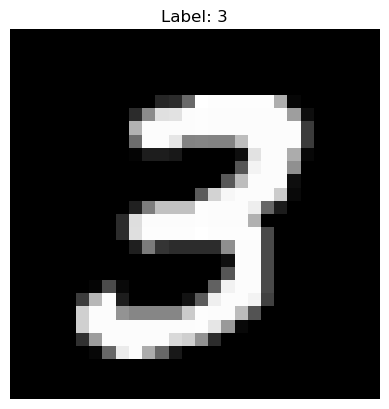

In [3]:

index = 7
image_data = X[index]  
label = y[index]       
image_reshaped = image_data.reshape(28, 28)


plt.imshow(image_reshaped, cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')  # Hide the axes
plt.show()

#### Part 1. Principal Component Analysis (40 marks = 20+10+10)

In [11]:
import numpy as np
import pandas as pd
from scipy.linalg import eigh


In [12]:
np.isnan(np.sum(X))

False

##### (a) Perform PCA on the MNIST dataset. Determine the minimum number of principal components required to retain at least 95% of the total variance. Plot the proportion of variance (PoV) against the number of principal components

In [13]:
X_mean = np.mean(X,axis=0)

X_centered = (X - X_mean)

X_centered

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
# computing covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

In [15]:
# Compute eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [16]:
# Sort the eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

In [17]:
# Compute the explained variance ratio and cumulative explained variance
total_variance = np.sum(eigenvalues_sorted)
explained_variance_ratio = eigenvalues_sorted / total_variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [18]:
# Determine the minimum number of principal components for at least 95% variance
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to retain at least 95% variance: {n_components_95}")


Number of components to retain at least 95% variance: 154


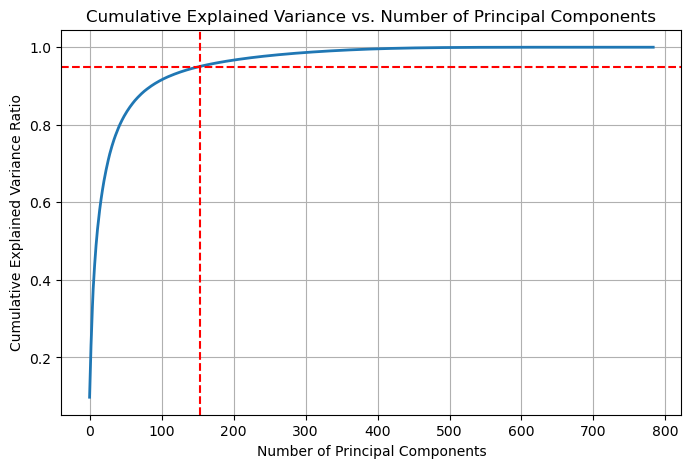

In [19]:
# Plot the proportion of variance (PoV) against the number of principal components
plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.axvline(x=n_components_95, color='r', linestyle='--')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

##### (b) Visualize the top 16 eigenvectors (principal components) as images. Provide the reconstruction of one sample image from each digit (0-9) using only the top 16 principal components.

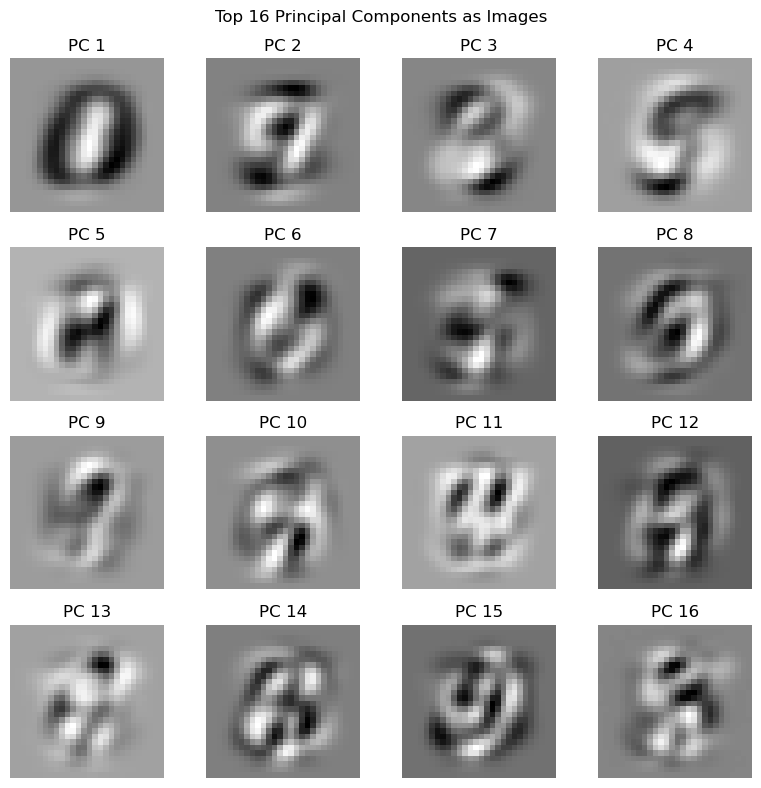

In [20]:
# Select the top 16 principal components
top_16_eigenvectors = eigenvectors_sorted[:, :16]  # Shape: (784, 16)

# Visualize the top 16 eigenvectors as images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()
for i in range(16):
    eigenvector_image = top_16_eigenvectors[:, i].reshape(28, 28)
    axes[i].imshow(eigenvector_image, cmap='gray')
    axes[i].set_title(f'PC {i+1}')
    axes[i].axis('off')
plt.suptitle('Top 16 Principal Components as Images')
plt.tight_layout()
plt.show()



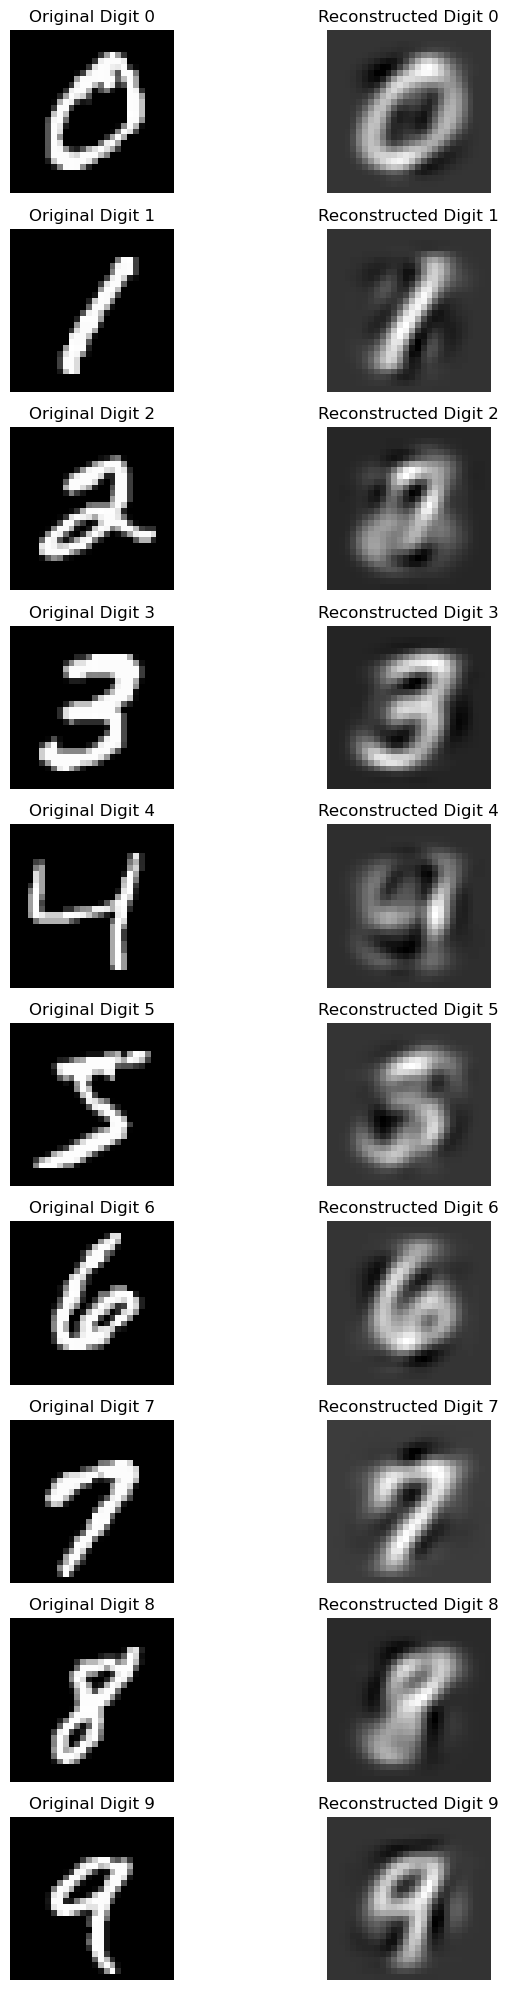

In [21]:
# Select one sample image for each digit (0-9)
sample_indices = []
for digit in range(10):
    index = np.where(y == digit)[0][0]
    sample_indices.append(index)

# Reconstruct each sample image using only the top 16 principal components
fig, axes = plt.subplots(10, 2, figsize=(8, 20))
for i, idx in enumerate(sample_indices):
    original_image = X_centered[idx]
    # Project onto the top 16 principal components
    projection = np.dot(original_image, top_16_eigenvectors)
    # Reconstruct the image from the projection
    reconstructed_image = np.dot(projection, top_16_eigenvectors.T)
    # Add the mean back to get the original scale
    reconstructed_image += X_mean
    # Reshape images for visualization
    original_image_reshaped = (original_image + X_mean).reshape(28, 28)
    reconstructed_image_reshaped = (reconstructed_image).reshape(28, 28)
    # Display original and reconstructed images
    axes[i, 0].imshow(original_image_reshaped, cmap='gray')
    axes[i, 0].set_title(f'Original Digit {y[idx]}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(reconstructed_image_reshaped, cmap='gray')
    axes[i, 1].set_title(f'Reconstructed Digit {y[idx]}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

(c) Run a k-NN classifier (k=10) on:
● The raw data.
● The data was reduced to the number of dimensions found in part (a).
● The data was reduced to 16 dimensions, as in part (b).
Report the accuracy of the predictions on the test dataset for each case and discuss
your observations regarding the impact of dimensionality reduction on classifier
performance.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
# Use the existing train and test sets
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Center the training and test data using the mean calculated from the combined dataset
X_train_centered = X_train - X_mean
X_test_centered = X_test - X_mean



In [23]:
# k-NN on raw data
knn_raw = KNeighborsClassifier(n_neighbors=10)
knn_raw.fit(X_train_centered, y_train)
y_pred_raw = knn_raw.predict(X_test_centered)
accuracy_raw = accuracy_score(y_test, y_pred_raw)
print(f"Accuracy on raw data: {accuracy_raw:.4f}")

# k-NN on data reduced to n_components_95 dimensions
top_n_eigenvectors = eigenvectors_sorted[:, :n_components_95]
X_train_pca_95 = np.dot(X_train_centered, top_n_eigenvectors)
X_test_pca_95 = np.dot(X_test_centered, top_n_eigenvectors)

knn_pca_95 = KNeighborsClassifier(n_neighbors=10)
knn_pca_95.fit(X_train_pca_95, y_train)
y_pred_pca_95 = knn_pca_95.predict(X_test_pca_95)
accuracy_pca_95 = accuracy_score(y_test, y_pred_pca_95)
print(f"Accuracy with {n_components_95} PCA components: {accuracy_pca_95:.4f}")

# k-NN on data reduced to 16 dimensions
top_16_eigenvectors = eigenvectors_sorted[:, :16]
X_train_pca_16 = np.dot(X_train_centered, top_16_eigenvectors)
X_test_pca_16 = np.dot(X_test_centered, top_16_eigenvectors)

knn_pca_16 = KNeighborsClassifier(n_neighbors=10)
knn_pca_16.fit(X_train_pca_16, y_train)
y_pred_pca_16 = knn_pca_16.predict(X_test_pca_16)
accuracy_pca_16 = accuracy_score(y_test, y_pred_pca_16)
print(f"Accuracy with 16 PCA components: {accuracy_pca_16:.4f}")

Accuracy on raw data: 0.9658
Accuracy with 154 PCA components: 0.9694
Accuracy with 16 PCA components: 0.9619


### Part 2. Clustering (20 marks)


(d) Perform k-means clustering with k=10 on:
● The raw data.
● The data was reduced to the number of dimensions found in Q2(a).
● The data was reduced to 16 dimensions as in Q2(b)

In [24]:
def kmeans(X, k, max_iterations=100):
    # Randomly initialize centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    for iteration in range(max_iterations):
        # Assign clusters based on closest centroid
        distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
        cluster_labels = np.argmin(distances, axis=0)
        # Update centroids
        new_centroids = np.array([X[cluster_labels == i].mean(axis=0) for i in range(k)])
        # Check for convergence
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return centroids, cluster_labels

# k-means on raw data
print("Running k-means on raw data...")
centroids_raw, labels_raw = kmeans(X_train_centered, k=10)

# k-means on data reduced to n_components_95 dimensions
print(f"Running k-means on data reduced to {n_components_95} dimensions...")
X_train_pca_95 = np.dot(X_train_centered, eigenvectors_sorted[:, :n_components_95])
centroids_pca_95, labels_pca_95 = kmeans(X_train_pca_95, k=10)

# k-means on data reduced to 16 dimensions
print("Running k-means on data reduced to 16 dimensions...")
X_train_pca_16 = np.dot(X_train_centered, eigenvectors_sorted[:, :16])
centroids_pca_16, labels_pca_16 = kmeans(X_train_pca_16, k=10)



Running k-means on raw data...
Running k-means on data reduced to 154 dimensions...
Running k-means on data reduced to 16 dimensions...


Used only the training data for clustering. Investigate whether images of the same digit
are clustered together. For each cluster, display the image closest to the centroid.

/Users/soumyajitpal/packages/miniconda3/envs/ml_dlai_metal/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


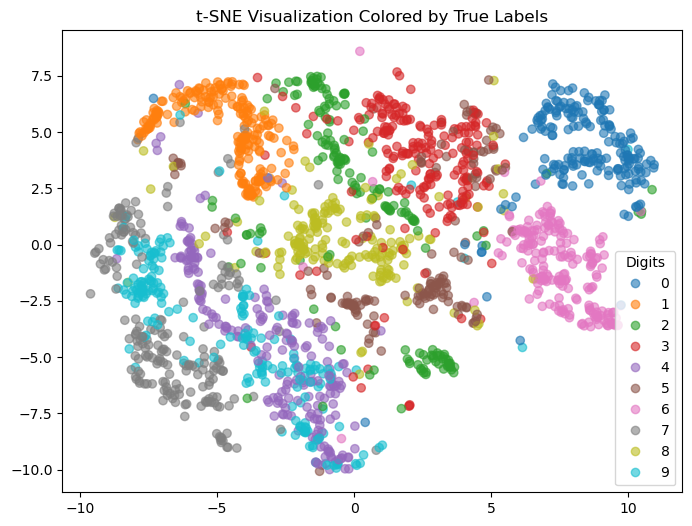

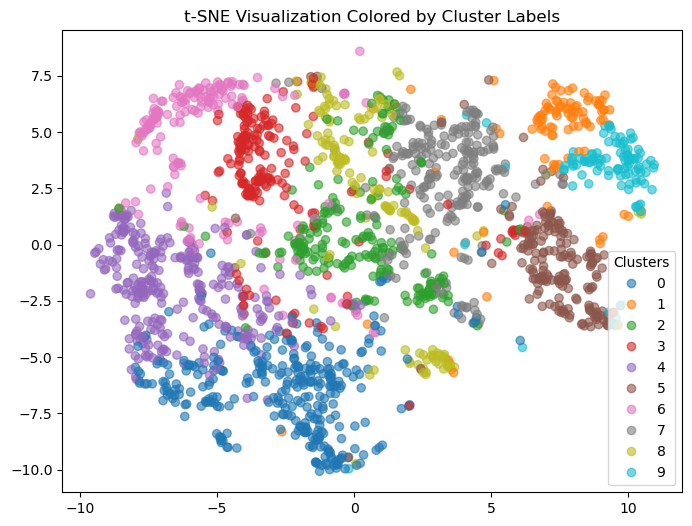

In [27]:
from sklearn.manifold import TSNE

# Use a subset for visualization
sample_size = 2000  # Adjust as necessary
sample_indices = np.random.choice(X_train_centered.shape[0], size=sample_size, replace=False)
X_sample = X_train_centered[sample_indices]
y_sample = y_train[sample_indices]
labels_sample = labels_raw[sample_indices]

# Perform t-SNE on the sample
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
X_tsne = tsne.fit_transform(X_sample)

# Plot t-SNE with true labels
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab10', alpha=0.6)
plt.legend(*scatter.legend_elements(), title='Digits')
plt.title('t-SNE Visualization Colored by True Labels')
plt.show()

# Plot t-SNE with cluster labels
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample, cmap='tab10', alpha=0.6)
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.title('t-SNE Visualization Colored by Cluster Labels')
plt.show()

if we observe closely and compare between the true labels and clusters we can see that , in most cases images of the same digits are clustered together , though the colors coding seems different , but clusters with the similar digits are clustered together we can understand from this 

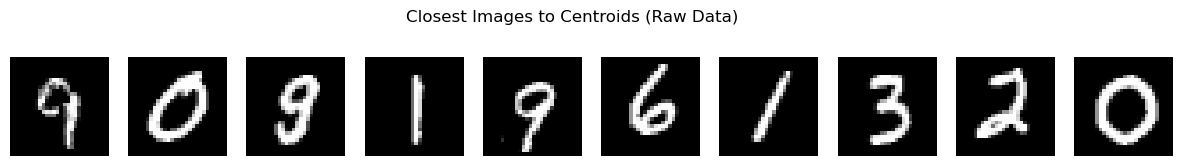

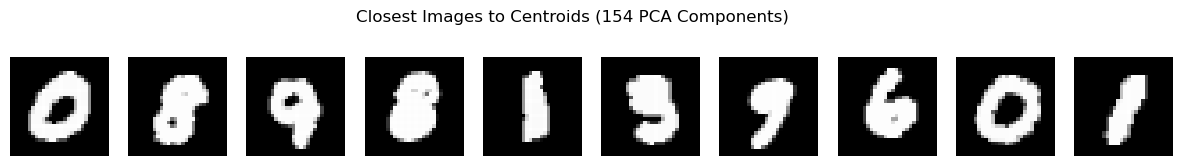

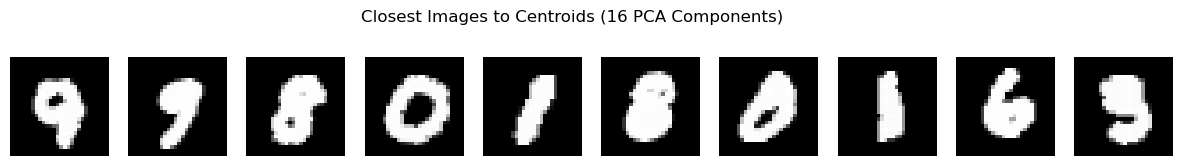

In [28]:
# Display image closest to the centroid for each cluster
def display_cluster_centers(centroids, X_original, eigenvectors=None, title=''):
    cluster_images = []
    for i in range(10):
        if eigenvectors is not None:
            # Reconstruct the centroid from PCA space to original space
            centroid_original = np.dot(centroids[i], eigenvectors.T) + X_mean  # Shape: (784,)
            # Compute distances in the original space
            distances = np.linalg.norm(X_original - centroid_original, axis=1)
        else:
            # Centroids are already in original space
            centroid_original = centroids[i] + X_mean  # Shape: (784,)
            distances = np.linalg.norm(X_original - centroids[i], axis=1)
        # Find the sample closest to the centroid
        closest_idx = np.argmin(distances)
        closest_image = (X_original[closest_idx] + X_mean).reshape(28, 28)
        cluster_images.append(closest_image)
    # Plot the images
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    for idx, ax in enumerate(axes):
        ax.imshow(cluster_images[idx], cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

# Display for raw data
display_cluster_centers(
    centroids_raw,
    X_train_centered,
    title='Closest Images to Centroids (Raw Data)'
)

# Display for PCA reduced data (n_components_95)
display_cluster_centers(
    centroids_pca_95,
    X_train_centered,  # Use the centered original data
    eigenvectors=eigenvectors_sorted[:, :n_components_95],
    title=f'Closest Images to Centroids ({n_components_95} PCA Components)'
)

# Display for PCA reduced data (16 components)
display_cluster_centers(
    centroids_pca_16,
    X_train_centered,  # Use the centered original data
    eigenvectors=eigenvectors_sorted[:, :16],
    title='Closest Images to Centroids (16 PCA Components)'
)